# Experiment — Training diagnostics & overfitting

**Category:** diagnostics

Earlier notebooks reported a single test score. Here we look *inside* training to check for **overfitting** (train vs test gap, learning curves, validation curves) and report a **richer metric set** and **residual diagnostics**. Code is written inline so each step is visible.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

REPO = Path.cwd()
while not (REPO / "data").exists() and REPO != REPO.parent:
    REPO = REPO.parent
FIGS = REPO / "reports" / "figures"; FIGS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(REPO / "data" / "processed" / "grid_load_clean.csv")
print("clean data:", df.shape)
df.head()

clean data: (1489, 10)


,Region,Hour,DayOfWeek,Temperature_C,Humidity_pct,Rainfall_mm,PopulationIndex,IndustrialIndex,SolarGenerationIndex,GridLoad_MW
0,Central,20.0,0.0,26.7,52.0,3.1,93.0,89.0,0.03,850.3
1,Eastern,13.0,0.0,18.5,63.0,3.7,95.0,89.0,0.38,788.3
2,Western,14.0,4.0,22.7,90.0,3.3,71.0,55.0,0.13,548.0
3,Northern,10.0,0.0,19.6,41.0,0.1,75.0,78.0,0.45,604.6
4,Northern,12.0,0.0,27.4,88.0,0.0,86.0,58.0,0.70,546.1


In [2]:
# --- Feature engineering, written out inline so every step is visible ---
def make_features(frame):
    d = frame.copy()
    # cyclical time: hour 23 should sit next to hour 0
    d["Hour_sin"] = np.sin(2 * np.pi * d["Hour"] / 24)
    d["Hour_cos"] = np.cos(2 * np.pi * d["Hour"] / 24)
    d["DoW_sin"]  = np.sin(2 * np.pi * d["DayOfWeek"] / 7)
    d["DoW_cos"]  = np.cos(2 * np.pi * d["DayOfWeek"] / 7)
    # calendar flags
    d["is_weekend"]      = (d["DayOfWeek"] >= 5).astype(int)
    d["is_daytime"]      = d["Hour"].between(6, 18).astype(int)
    d["is_evening_peak"] = d["Hour"].between(18, 22).astype(int)
    # interactions (these turned out to matter most)
    d["Temp_x_Humidity"]  = d["Temperature_C"] * d["Humidity_pct"]
    d["Pop_x_Industrial"] = d["PopulationIndex"] * d["IndustrialIndex"]
    # region one-hot
    d = pd.concat([d.drop(columns=["Region"]),
                   pd.get_dummies(d["Region"], prefix="Region").astype(int)], axis=1)
    return d

feat = make_features(df)
y = feat["GridLoad_MW"]
X = feat.drop(columns=["GridLoad_MW"]).select_dtypes("number")
print("feature matrix:", X.shape)
X.head()

feature matrix: (1489, 21)


,Hour,DayOfWeek,Temperature_C,Humidity_pct,Rainfall_mm,PopulationIndex,IndustrialIndex,SolarGenerationIndex,Hour_sin,Hour_cos,...,DoW_cos,is_weekend,is_daytime,is_evening_peak,Temp_x_Humidity,Pop_x_Industrial,Region_Central,Region_Eastern,Region_Northern,Region_Western
0,20.0,0.0,26.7,52.0,3.1,93.0,89.0,0.03,-8.660254e-01,0.500000,...,1.000000,0,0,1,1388.4,8277.0,1,0,0,0
1,13.0,0.0,18.5,63.0,3.7,95.0,89.0,0.38,-2.588190e-01,-0.965926,...,1.000000,0,1,0,1165.5,8455.0,0,1,0,0
2,14.0,4.0,22.7,90.0,3.3,71.0,55.0,0.13,-5.000000e-01,-0.866025,...,-0.900969,0,1,0,2043.0,3905.0,0,0,0,1
3,10.0,0.0,19.6,41.0,0.1,75.0,78.0,0.45,5.000000e-01,-0.866025,...,1.000000,0,1,0,803.6,5850.0,0,0,1,0
4,12.0,0.0,27.4,88.0,0.0,86.0,58.0,0.70,1.224647e-16,-1.000000,...,1.000000,0,1,0,2411.2,4988.0,0,0,1,0


In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('train', X_train.shape, '| test', X_test.shape)

train (1191, 21) | test (298, 21)


## Train vs test gap — the first overfitting signal
A model that scores far better on train than test is memorising, not generalising.

In [4]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             median_absolute_error, max_error, explained_variance_score)

def all_metrics(yt, yp):
    yt, yp = np.asarray(yt, float), np.asarray(yp, float)
    m = yt != 0
    return {
        'RMSE': np.sqrt(mean_squared_error(yt, yp)),
        'MAE': mean_absolute_error(yt, yp),
        'MedAE': median_absolute_error(yt, yp),
        'MaxErr': max_error(yt, yp),
        'R2': r2_score(yt, yp),
        'ExplVar': explained_variance_score(yt, yp),
        'MAPE%': np.mean(np.abs((yt[m]-yp[m])/yt[m]))*100,
    }

models = {
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
}
rows = []
for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    tr = all_metrics(y_train, mdl.predict(X_train))
    te = all_metrics(y_test,  mdl.predict(X_test))
    rows.append({'model': name, 'train_RMSE': tr['RMSE'], 'test_RMSE': te['RMSE'],
                 'gap': te['RMSE']-tr['RMSE'], 'train_R2': tr['R2'], 'test_R2': te['R2']})
gap = pd.DataFrame(rows).set_index('model').round(3)
gap

,train_RMSE,test_RMSE,gap,train_R2,test_R2
model,,,,,
Ridge,12.561,12.762,0.202,0.985,0.984
RandomForest,6.902,18.944,12.042,0.995,0.965
GradientBoosting,8.350,12.857,4.506,0.993,0.984


In [5]:
# full metric scorecard on the test set
score = {name: all_metrics(y_test, m.predict(X_test)) for name, m in models.items()}
pd.DataFrame(score).T.round(3)

,RMSE,MAE,MedAE,MaxErr,R2,ExplVar,MAPE%
Ridge,12.762,10.082,8.327,40.436,0.984,0.984,1.689
RandomForest,18.944,14.810,12.278,61.613,0.965,0.965,2.482
GradientBoosting,12.857,10.228,8.484,40.689,0.984,0.984,1.706


**Reading the gap:** RandomForest typically shows a large train-vs-test gap (near-perfect on train) = classic overfit. Ridge shows almost no gap = underfit-safe. GradientBoosting sits in between.

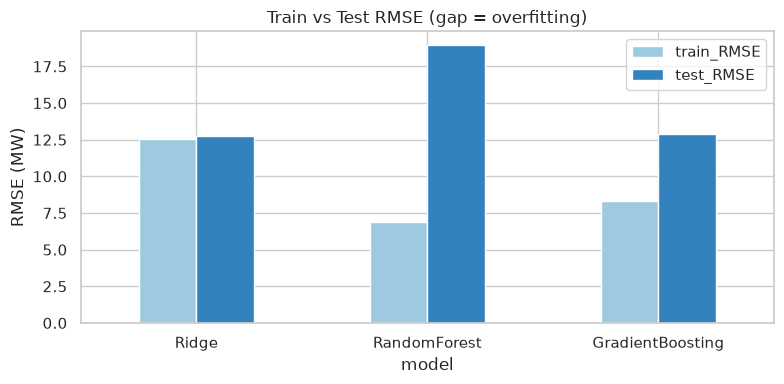

In [6]:
fig, ax = plt.subplots(figsize=(8,4))
gap[['train_RMSE','test_RMSE']].plot.bar(ax=ax, color=['#9ecae1','#3182bd'])
ax.set_ylabel('RMSE (MW)'); ax.set_title('Train vs Test RMSE (gap = overfitting)')
plt.xticks(rotation=0); fig.tight_layout()
fig.savefig(FIGS/'diag_train_test_gap.png', dpi=120); plt.show()

## Learning curve
Does more data help, and do train/validation curves converge? A large persistent gap = high variance (overfit); both curves high & flat = high bias (underfit).

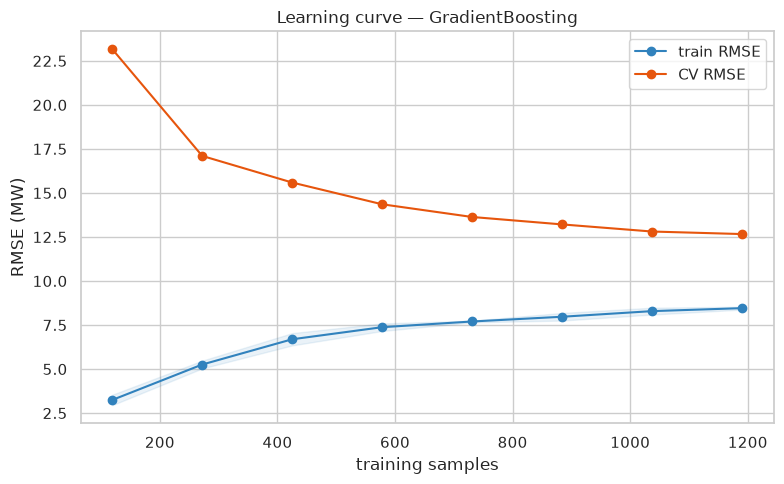

In [7]:
from sklearn.model_selection import learning_curve
sizes, tr_sc, va_sc = learning_curve(
    GradientBoostingRegressor(random_state=42), X, y,
    train_sizes=np.linspace(0.1, 1.0, 8), cv=5,
    scoring='neg_root_mean_squared_error', n_jobs=-1, random_state=42)
tr_rmse, va_rmse = -tr_sc.mean(1), -va_sc.mean(1)
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(sizes, tr_rmse, 'o-', label='train RMSE', color='#3182bd')
ax.plot(sizes, va_rmse, 'o-', label='CV RMSE', color='#e6550d')
ax.fill_between(sizes, -tr_sc.mean(1)-tr_sc.std(1), -tr_sc.mean(1)+tr_sc.std(1), alpha=.1, color='#3182bd')
ax.set_xlabel('training samples'); ax.set_ylabel('RMSE (MW)')
ax.set_title('Learning curve — GradientBoosting'); ax.legend()
fig.tight_layout(); fig.savefig(FIGS/'diag_learning_curve.png', dpi=120); plt.show()

## Validation curves — where complexity starts to overfit
Sweep one hyperparameter, watch train vs CV. The point where CV stops improving (or worsens) while train keeps dropping is the overfitting onset.

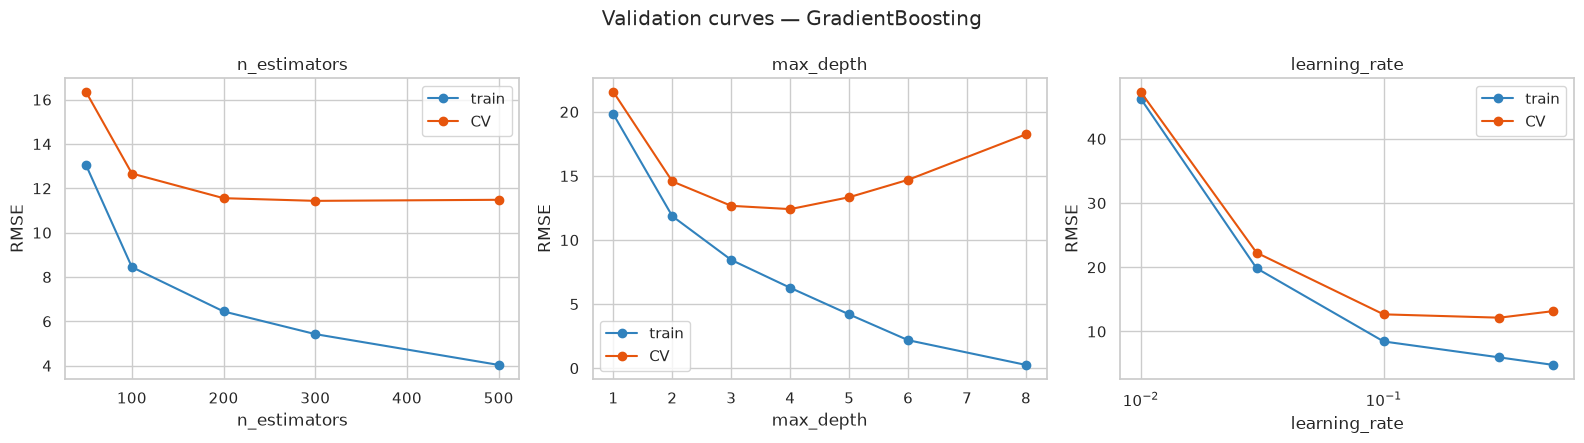

In [8]:
from sklearn.model_selection import validation_curve
def val_curve(param, rng, ax, logx=False):
    tr, va = validation_curve(GradientBoostingRegressor(random_state=42), X, y,
        param_name=param, param_range=rng, cv=5,
        scoring='neg_root_mean_squared_error', n_jobs=-1)
    ax.plot(rng, -tr.mean(1), 'o-', label='train', color='#3182bd')
    ax.plot(rng, -va.mean(1), 'o-', label='CV', color='#e6550d')
    if logx: ax.set_xscale('log')
    ax.set_xlabel(param); ax.set_ylabel('RMSE'); ax.set_title(param); ax.legend()

fig, axes = plt.subplots(1, 3, figsize=(16,4.5))
val_curve('n_estimators', [50,100,200,300,500], axes[0])
val_curve('max_depth', [1,2,3,4,5,6,8], axes[1])
val_curve('learning_rate', [0.01,0.03,0.1,0.3,0.5], axes[2], logx=True)
fig.suptitle('Validation curves — GradientBoosting'); fig.tight_layout()
fig.savefig(FIGS/'diag_validation_curves.png', dpi=120); plt.show()

## Residual diagnostics
Residuals of a good model should be small, centred on 0, patternless.

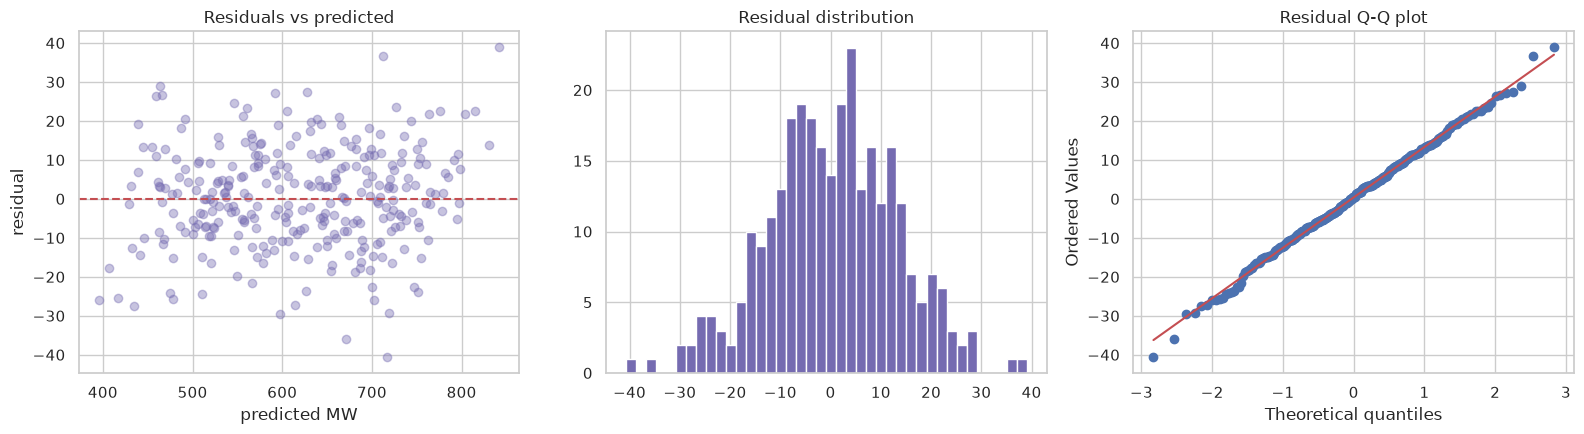

In [9]:
gb = GradientBoostingRegressor(random_state=42).fit(X_train, y_train)
pred = gb.predict(X_test); resid = y_test - pred
fig, ax = plt.subplots(1, 3, figsize=(16,4.5))
ax[0].scatter(pred, resid, alpha=.4, color='#756bb1'); ax[0].axhline(0, color='r', ls='--')
ax[0].set_xlabel('predicted MW'); ax[0].set_ylabel('residual'); ax[0].set_title('Residuals vs predicted')
ax[1].hist(resid, bins=40, color='#756bb1', edgecolor='white'); ax[1].set_title('Residual distribution')
from scipy import stats
stats.probplot(resid, dist='norm', plot=ax[2]); ax[2].set_title('Residual Q-Q plot')
fig.tight_layout(); fig.savefig(FIGS/'diag_residuals.png', dpi=120); plt.show()

## Where does error concentrate? (by region & hour)
Aggregate error breakdowns show *when* the model struggles — useful for the report.

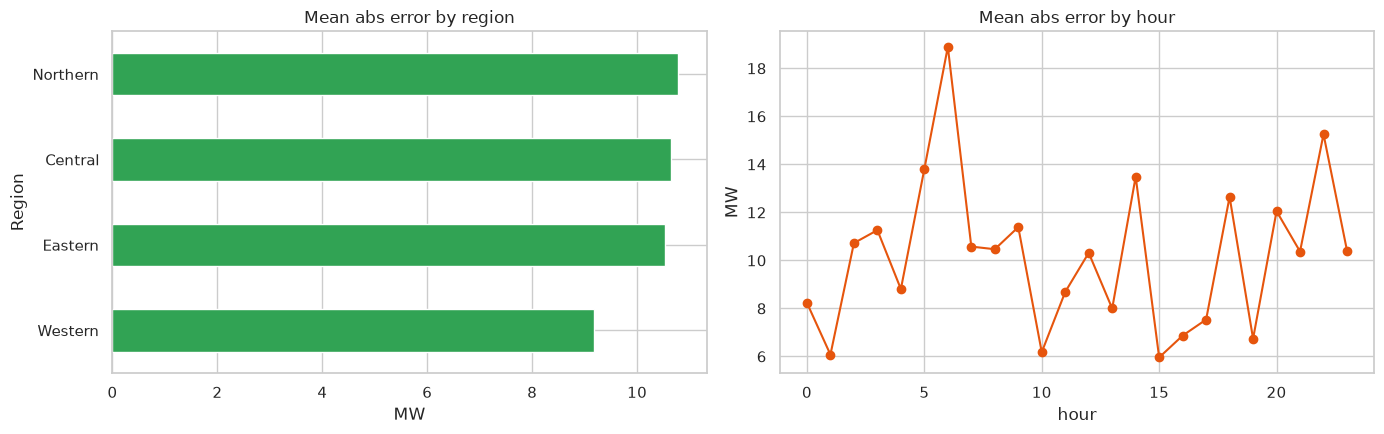

In [10]:
err = df.loc[y_test.index].copy()
err['abs_err'] = np.abs(resid.values)
fig, ax = plt.subplots(1, 2, figsize=(14,4.5))
err.groupby('Region')['abs_err'].mean().sort_values().plot.barh(ax=ax[0], color='#31a354')
ax[0].set_title('Mean abs error by region'); ax[0].set_xlabel('MW')
err.groupby('Hour')['abs_err'].mean().plot(marker='o', ax=ax[1], color='#e6550d')
ax[1].set_title('Mean abs error by hour'); ax[1].set_xlabel('hour'); ax[1].set_ylabel('MW')
fig.tight_layout(); fig.savefig(FIGS/'diag_error_breakdown.png', dpi=120); plt.show()

## Diagnostic takeaways
- **RandomForest overfits** (big train-test gap); GradientBoosting generalises better.
- **Learning curve** converges → we have enough data; more rows won't help much (motivates *augmentation* and *tuning* rather than data collection — see the next two notebooks).
- **Validation curves** pinpoint safe hyperparameter ranges (shallow trees, moderate n_estimators) → fed into `tuning_01_gradient_boosting.ipynb`.
- **Residuals** are roughly centred/patternless; error is fairly uniform across regions/hours.